# **Iris Flower Classification with a Keras Feed‑Forward Neural Network**

This notebook demonstrates a complete workflow for training and evaluating a feed‑forward neural network using Keras to classify iris flowers into three species: Setosa, Versicolor, and Virginica.

The project covers:
- loading and preprocessing the Iris dataset
- encoding categorical labels
- splitting the data into training and test sets
- building a multi‑layer perceptron (MLP) with Keras
- training the model and monitoring performance
- evaluating accuracy through a classification report and confusion matrix
- saving and reloading the trained model for inference

This notebook was originally developed as a personal learning exercise and has been updated and documented for portfolio purposes.

**Note:** You may either train the model from scratch or load the pre‑trained model (model1.h5) and proceed directly to inference. If you already have a trained model, simply run cell 7 to load it, and then use cell 8 and/or cell 9 to test the model.

## 1. Load dataset

In [1]:
import pandas as pd

"""
Load the Iris dataset into a pandas DataFrame.
The first four columns (sepal length, sepal width, petal length, petal width)
are stored in the feature matrix X, while the last column (variety) is stored
in the target array y.
"""

df = pd.read_csv("iris.csv")
X = df.iloc[:, :-1].values # all columns except the last
y = df.iloc[:, -1].values # last column (species)
df.head()


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## 2. Preprocess data

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
#import pandas as pd

"""
Encode the target labels (Setosa, Versicolor, Virginica) using LabelEncoder
and one‑hot encoding. Then standardize the feature matrix X and split the
dataset into training and test sets.
"""

# Encode labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
Y = pd.get_dummies(y_encoded).values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=0
)

## 3. Build the model

In [3]:
from keras.models import Sequential
from keras.layers import Dense, Input

"""
Build a simple feed‑forward neural network (MLP) for ternary classification.
The model consists of two hidden layers with ReLU activation and a softmax
output layer for the three iris species.
"""

model = Sequential([
    Input(shape=(4,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Train and evaluate the model

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.2868 - loss: 1.2590 - val_accuracy: 0.4583 - val_loss: 1.1371
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2840 - loss: 1.2185 - val_accuracy: 0.4583 - val_loss: 1.1118
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2604 - loss: 1.1770 - val_accuracy: 0.4583 - val_loss: 1.0888
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3028 - loss: 1.1237 - val_accuracy: 0.5000 - val_loss: 1.0668
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3597 - loss: 1.1075 - val_accuracy: 0.5833 - val_loss: 1.0465
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4854 - loss: 1.0757 - val_accuracy: 0.7083 - val_loss: 1.0267
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5722 - loss: 1.0516 - val_accuracy: 0.7083 - val_loss: 1.0074
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5840 - loss: 1.0220 - val_accuracy: 0.7083 - val_loss:

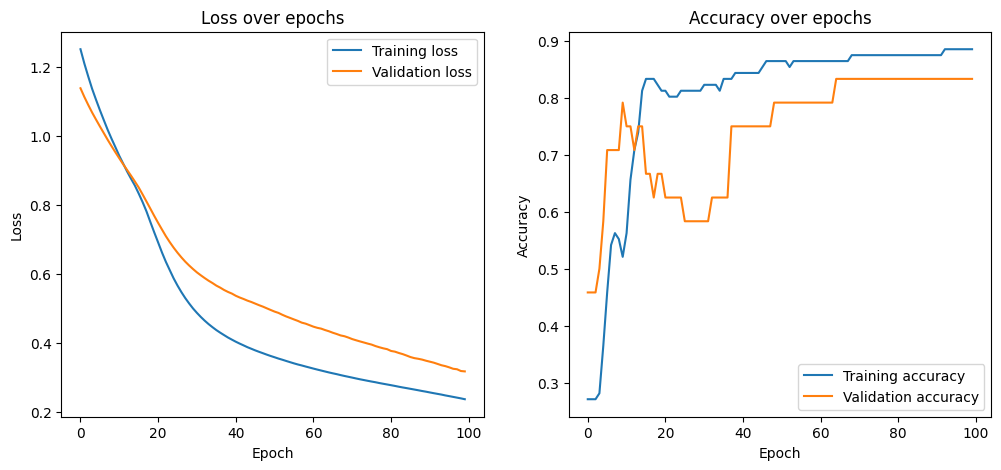

In [4]:
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

"""
Compile and train the neural network using Adam optimizer and categorical
cross‑entropy loss. Early stopping is applied to prevent overfitting, and
a validation split is used to monitor performance during training.
"""

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=20,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on the test set
results = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

# Plot training curves
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## 5. Advanced Evaluation

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Classification Report:

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        11
  Versicolor       1.00      0.54      0.70        13
   Virginica       0.50      1.00      0.67         6

    accuracy                           0.80        30
   macro avg       0.83      0.85      0.79        30
weighted avg       0.90      0.80      0.80        30



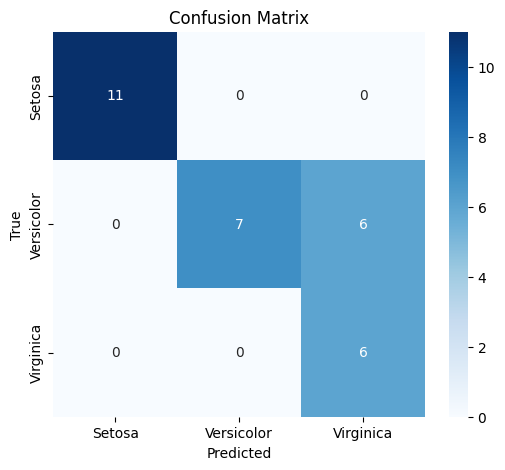

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

"""
Advanced evaluation of the trained model:
- generate predictions on the test set
- compute a classification report (precision, recall, F1-score)
- visualize the confusion matrix
"""

# Predictions on the test set
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)
y_true_classes = y_test.argmax(axis=1)

# Classification report
print("Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## 6. Save the model

In [ ]:
from pathlib import Path

output_path = Path("model1.h5")
model.save(output_path)
print(f"Model saved to {output_path.resolve()}")

## 7. Load Saved Model
### ⚠️ Run this only if the model was trained in a previous session


In [ ]:
from keras.models import load_model

"""
Load the trained model from the HDF5 file (model1.h5).
This allows running inference without retraining the network.
"""

model = load_model("model1.h5")
print("Model loaded successfully.")

## 8. Prediction examples

In [7]:
import numpy as np
import pandas as pd

"""
Generate a few example predictions using samples from the test set.
For each sample, display the input features, the true class, and the
predicted class produced by the trained model.
"""

# Number of examples to display
n_examples = 5

# Randomly select samples from the test set
indices = np.random.choice(len(X_test), n_examples, replace=False)

for idx in indices:
    sample = X_test[idx].reshape(1, -1)
    true_class = encoder.classes_[y_test[idx].argmax()]

    pred = model.predict(sample)
    pred_class = encoder.classes_[pred.argmax()]

    print(f"Sample features: {sample.flatten()}")
    print(f"True class:      {true_class}")
    print(f"Predicted class: {pred_class}")
    print("-" * 40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Sample features: [ 0.31099753 -0.59237301  0.13754657  0.13250973]
True class:      Versicolor
Predicted class: Versicolor
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Sample features: [ 0.31099753 -0.59237301  0.53540856  0.00087755]
True class:      Versicolor
Predicted class: Versicolor
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Sample features: [-1.02184904  0.78880759 -1.22655167 -1.05217993]
True class:      Setosa
Predicted class: Setosa
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Sample features: [ 0.31099753 -1.05276654  1.0469454   0.26414192]
True class:      Virginica
Predicted class: Virginica
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Sample features: [ 0.4321654  -0.59237301  0.59224599  0.79067065]
True class:      Virginica
Predicted class: Virginica
----------------------------------------


## 9. Test the Model Manually
### After running this cell, you can test the model by calling the predict_flower() function with your own input values.

In [ ]:
def predict_flower(sepal_length, sepal_width, petal_length, petal_width):
    """
    Predict the iris species given the four flower measurements.
    """
    sample = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    sample_scaled = scaler.transform(sample)  # use the same scaler used during training

    pred = model.predict(sample_scaled)
    pred_class = encoder.classes_[pred.argmax()]

    return pred_class